# Hierarchical Scoring for ENVO Predictions

Comprehensive evaluation of Random Forest predictions using hierarchical ontology-aware scoring.
Compares multiple approaches: exact-match vs hierarchical, with vs without deduplication.

## Setup

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path('../src').absolute()))

In [2]:
from env_embeddings.rf_analysis import (
    load_source_data,
    train_rf_model,
)
from env_embeddings.ontology_metrics import (
    ENVOHierarchy,
    hierarchical_score,
)

In [3]:
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Load ENVO Hier_F1archy

In [4]:
print('Loading ENVO ontology...')
ontology = ENVOHierarchy()
print('ENVO loaded successfully via oaklib')

Loading ENVO ontology...
ENVO loaded successfully via oaklib


## Load Data

In [5]:
SOURCES = {
    'GOLD': Path('../data/gold_flattened_biosamples_for_env_embeddings_202510061108_complete.csv'),
    'NMDC': Path('../data/nmdc_flattened_biosample_for_env_embeddings_202510061052_complete.csv'),
    'NCBI': Path('../data/ncbi_flattened_biosamples_for_env_embeddings_202510061108_normalized_complete.csv'),
}

datasets_no_dedup = {}
for source_name, file_path in SOURCES.items():
    if source_name == 'NCBI':
        print(f'Skipping {source_name} for non-dedup (too large)')
        continue
    df = load_source_data(file_path, source_name, deduplicate=False)
    if df is not None:
        datasets_no_dedup[source_name] = df


Loading GOLD
  Loaded: 10,401 rows
  Complete data: 10,401 rows
  Valid embeddings: 10,401 rows

  ENVO scale class counts:
    env_broad_scale     :   40 classes
    env_local_scale     :  139 classes
    env_medium          :   78 classes

Loading NMDC
  Loaded: 8,121 rows
  Complete data: 8,121 rows
  Valid embeddings: 8,121 rows

  ENVO scale class counts:
    env_broad_scale     :   19 classes
    env_local_scale     :   51 classes
    env_medium          :   30 classes
Skipping NCBI for non-dedup (too large)


In [6]:
datasets_dedup = {}
for source_name, file_path in SOURCES.items():
    df = load_source_data(file_path, source_name, deduplicate=False)
    if df is None:
        continue
    print(f'Deduplicating {source_name}...')
    initial_count = len(df)
    df_dedup = df.drop_duplicates(
        subset=['latitude', 'longitude', 'collection_date',
                'env_broad_scale', 'env_local_scale', 'env_medium'],
        keep='first',
    ).copy()
    removed = initial_count - len(df_dedup)
    pct_removed = removed / initial_count * 100
    print(f'  {len(df_dedup):,} rows (removed {removed:,} = {pct_removed:.1f}%)')
    datasets_dedup[source_name] = df_dedup


Loading GOLD
  Loaded: 10,401 rows
  Complete data: 10,401 rows
  Valid embeddings: 10,401 rows

  ENVO scale class counts:
    env_broad_scale     :   40 classes
    env_local_scale     :  139 classes
    env_medium          :   78 classes
Deduplicating GOLD...
  4,198 rows (removed 6,203 = 59.6%)

Loading NMDC
  Loaded: 8,121 rows
  Complete data: 8,121 rows
  Valid embeddings: 8,121 rows

  ENVO scale class counts:
    env_broad_scale     :   19 classes
    env_local_scale     :   51 classes
    env_medium          :   30 classes
Deduplicating NMDC...
  4,646 rows (removed 3,475 = 42.8%)

Loading NCBI
  Loaded: 382,955 rows
  Complete data: 382,955 rows
  Valid embeddings: 382,955 rows

  ENVO scale class counts:
    env_broad_scale     :  570 classes
    env_local_scale     :  829 classes
    env_medium          :  562 classes
Deduplicating NCBI...
  73,197 rows (removed 309,758 = 80.9%)


## Train Models - No Deduplication

In [7]:
results_no_dedup = {}
hier_results_no_dedup = {}

for source_name, df in datasets_no_dedup.items():
    results_no_dedup[source_name] = {}
    hier_results_no_dedup[source_name] = {}
    print(f'\nTraining: {source_name} (no dedup)')

    for scale in ['env_broad_scale', 'env_local_scale', 'env_medium']:
        X = np.vstack(df['ge_embedding'].values)
        y = df[scale].values
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=RANDOM_STATE
        )

        result = train_rf_model(X_train, y_train, X_test, y_test)
        results_no_dedup[source_name][scale] = result

        y_pred = result['y_test_pred']
        scores = [hierarchical_score(pred, true, ontology)
                  for pred, true in zip(y_pred, y_test)]
        hier_f1 = np.mean(scores)
        exact_f1 = result['test_f1']

        hier_results_no_dedup[source_name][scale] = {
            'exact_f1': exact_f1,
            'hier_f1': hier_f1,
            'improvement': hier_f1 - exact_f1,
            'n_classes': result['n_classes'],
            'scores': scores,
        }
        print(f'  {scale}: {exact_f1:.4f} -> {hier_f1:.4f} (+{hier_f1-exact_f1:.4f})')


Training: GOLD (no dedup)
  env_broad_scale: 0.9188 -> 0.9691 (+0.0503)
  env_local_scale: 0.8201 -> 0.8930 (+0.0729)
  env_medium: 0.8336 -> 0.9193 (+0.0857)

Training: NMDC (no dedup)
  env_broad_scale: 0.9666 -> 0.9832 (+0.0167)
  env_local_scale: 0.8705 -> 0.9348 (+0.0643)
  env_medium: 0.9154 -> 0.9529 (+0.0375)


## Train Models - With Deduplication

In [8]:
results_dedup = {}
hier_results_dedup = {}

for source_name, df in datasets_dedup.items():
    results_dedup[source_name] = {}
    hier_results_dedup[source_name] = {}
    print(f'\nTraining: {source_name} (dedup)')

    for scale in ['env_broad_scale', 'env_local_scale', 'env_medium']:
        X = np.vstack(df['ge_embedding'].values)
        y = df[scale].values
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=RANDOM_STATE
        )

        result = train_rf_model(X_train, y_train, X_test, y_test)
        results_dedup[source_name][scale] = result

        y_pred = result['y_test_pred']
        scores = [hierarchical_score(pred, true, ontology)
                  for pred, true in zip(y_pred, y_test)]
        hier_f1 = np.mean(scores)
        exact_f1 = result['test_f1']

        hier_results_dedup[source_name][scale] = {
            'exact_f1': exact_f1,
            'hier_f1': hier_f1,
            'improvement': hier_f1 - exact_f1,
            'n_classes': result['n_classes'],
            'scores': scores,
        }
        print(f'  {scale}: {exact_f1:.4f} -> {hier_f1:.4f} (+{hier_f1-exact_f1:.4f})')


Training: GOLD (dedup)
  env_broad_scale: 0.8154 -> 0.9274 (+0.1120)
  env_local_scale: 0.6779 -> 0.8307 (+0.1527)
  env_medium: 0.7256 -> 0.8738 (+0.1482)

Training: NMDC (dedup)
  env_broad_scale: 0.9513 -> 0.9798 (+0.0286)
  env_local_scale: 0.8257 -> 0.9161 (+0.0904)
  env_medium: 0.8552 -> 0.9306 (+0.0754)

Training: NCBI (dedup)
  env_broad_scale: 0.3555 -> 0.6479 (+0.2924)
  env_local_scale: 0.3066 -> 0.6125 (+0.3059)
  env_medium: 0.3729 -> 0.6520 (+0.2791)


In [9]:
# Create dataframes for plotting
rows_no_dedup = []
for source, scales in hier_results_no_dedup.items():
    for scale, metrics in scales.items():
        rows_no_dedup.append({
            'Source': source,
            'Scale': scale.replace('env_', ''),
            'Exact_F1': metrics['exact_f1'],
            'Hier_F1': metrics['hier_f1'],
            'Improvement': metrics['improvement']
        })
df_no_dedup = pd.DataFrame(rows_no_dedup)

rows_dedup = []
for source, scales in hier_results_dedup.items():
    for scale, metrics in scales.items():
        rows_dedup.append({
            'Source': source,
            'Scale': scale.replace('env_', ''),
            'Exact_F1': metrics['exact_f1'],
            'Hier_F1': metrics['hier_f1'],
            'Improvement': metrics['improvement']
        })
df_dedup = pd.DataFrame(rows_dedup)

score_data = []
for source in sorted(hier_results_dedup.keys()):
    for scale in ['env_broad_scale', 'env_local_scale', 'env_medium']:
        if scale not in hier_results_dedup[source]:
            continue
        scores = np.array(hier_results_dedup[source][scale]['scores'])
        score_data.append({
            'Source': source,
            'Scale': scale.replace('env_', ''),
            'Exact_F1_1.0': np.sum(scores == 1.0),
            '1hop_0.75': np.sum(scores == 0.75),
            '2hop_0.50': np.sum(scores == 0.50),
            '3+hop_0.25': np.sum(scores == 0.25),
            'Unrelated_0.0': np.sum(scores == 0.0),
        })

df_scores = pd.DataFrame(score_data)

print("DataFrames for plotting created successfully.")

DataFrames for plotting created successfully.


fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_no_dedup))
width = 0.35

ax.bar(x - width/2, df_no_dedup['Exact_F1'], width, label='Exact_F1', alpha=0.8)
ax.bar(x + width/2, df_no_dedup['Hier_F1'], width, label='Hierarchical', alpha=0.8)

ax.set_ylabel('F1 Score')
ax.set_title('Exact_F1 vs Hierarchical F1 Score (No Deduplication)')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Source']}\n{r['Scale']}" for _, r in df_no_dedup.iterrows()],
                   rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

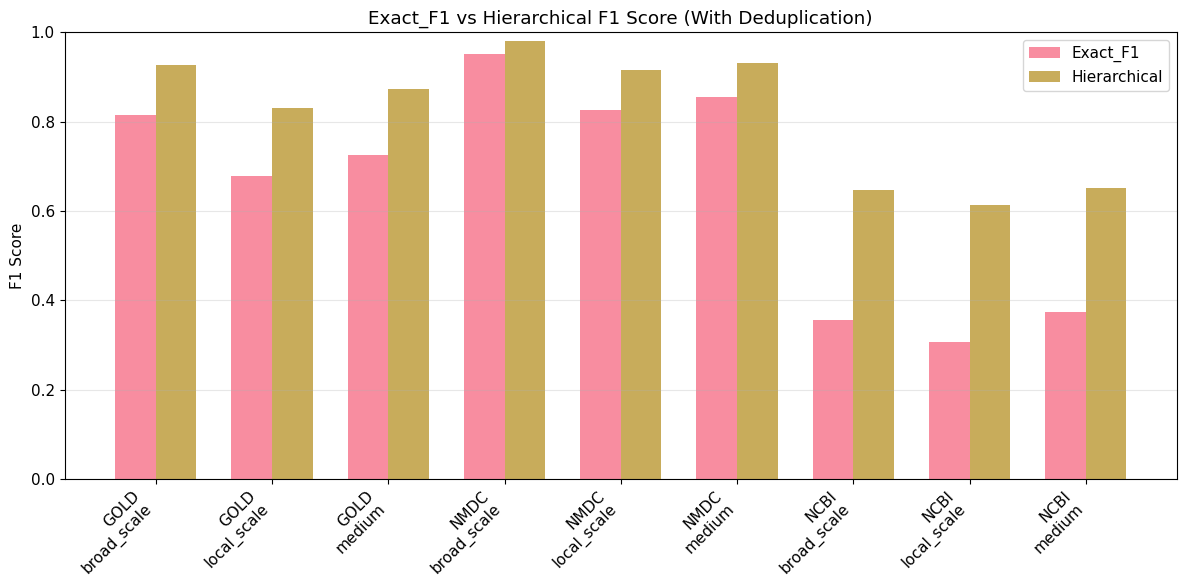

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_dedup))
width = 0.35

ax.bar(x - width/2, df_dedup['Exact_F1'], width, label='Exact_F1', alpha=0.8)
ax.bar(x + width/2, df_dedup['Hier_F1'], width, label='Hierarchical', alpha=0.8)

ax.set_ylabel('F1 Score')
ax.set_title('Exact_F1 vs Hierarchical F1 Score (With Deduplication)')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Source']}\n{r['Scale']}" for _, r in df_dedup.iterrows()],
                   rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization: Exact_F1 vs Hierarchical (No Dedup)

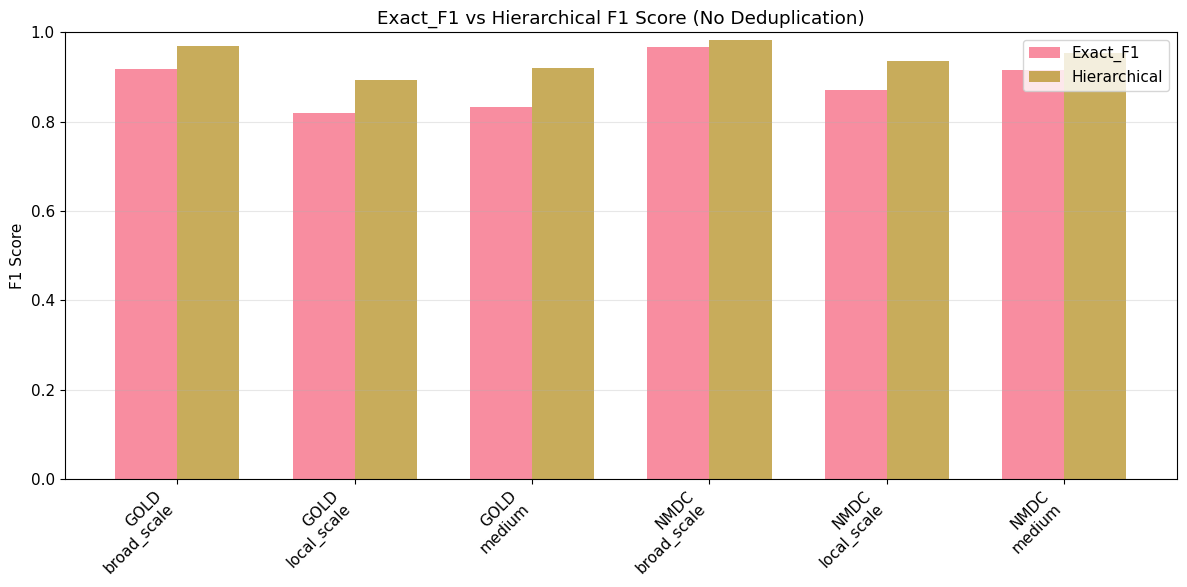

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_no_dedup))
width = 0.35

ax.bar(x - width/2, df_no_dedup['Exact_F1'], width, label='Exact_F1', alpha=0.8)
ax.bar(x + width/2, df_no_dedup['Hier_F1'], width, label='Hierarchical', alpha=0.8)

ax.set_ylabel('F1 Score')
ax.set_title('Exact_F1 vs Hierarchical F1 Score (No Deduplication)')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Source']}\n{r['Scale']}" for _, r in df_no_dedup.iterrows()],
                   rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_scores))
width = 0.6
bottom = np.zeros(len(df_scores))

colors = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b', '#95a5a6']
labels = ['Exact_F1 (1.0)', '1-hop (0.75)', '2-hop (0.50)', '3+-hop (0.25)', 'Unrelated (0.0)']
columns = ['Exact_F1_1.0', '1hop_0.75', '2hop_0.50', '3+hop_0.25', 'Unrelated_0.0']

for col, label, color in zip(columns, labels, colors):
    ax.bar(x, df_scores[col], width, label=label, bottom=bottom, color=color, alpha=0.8)
    bottom += df_scores[col].values

ax.set_ylabel('Number of Predictions')
ax.set_title('Distribution of Hierarchical Scores (With Deduplication)')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Source']}\n{r['Scale']}" for _, r in df_scores.iterrows()],
                   rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

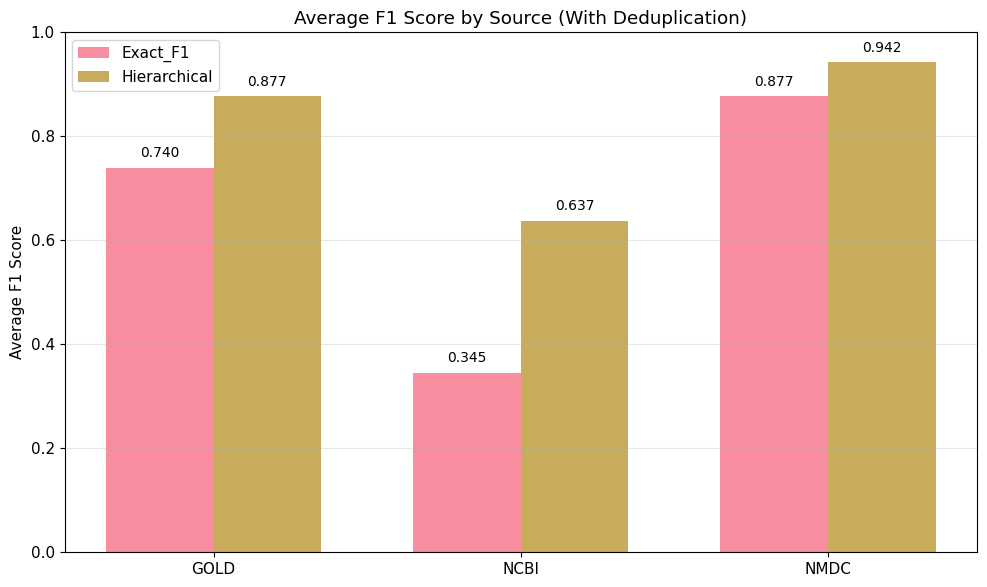

In [12]:
summary_src = df_dedup.groupby('Source')[['Exact_F1', 'Hier_F1']].mean()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(summary_src))
width = 0.35

ax.bar(x - width/2, summary_src['Exact_F1'], width, label='Exact_F1', alpha=0.8)
ax.bar(x + width/2, summary_src['Hier_F1'], width, label='Hierarchical', alpha=0.8)

ax.set_ylabel('Average F1 Score')
ax.set_title('Average F1 Score by Source (With Deduplication)')
ax.set_xticks(x)
ax.set_xticklabels(summary_src.index)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (exact, hier) in enumerate(zip(summary_src['Exact_F1'], summary_src['Hier_F1'])):
    ax.text(i - width/2, exact + 0.02, f'{exact:.3f}', ha='center', fontsize=10)
    ax.text(i + width/2, hier + 0.02, f'{hier:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Visualization: Hierarchical Improvement by Scale

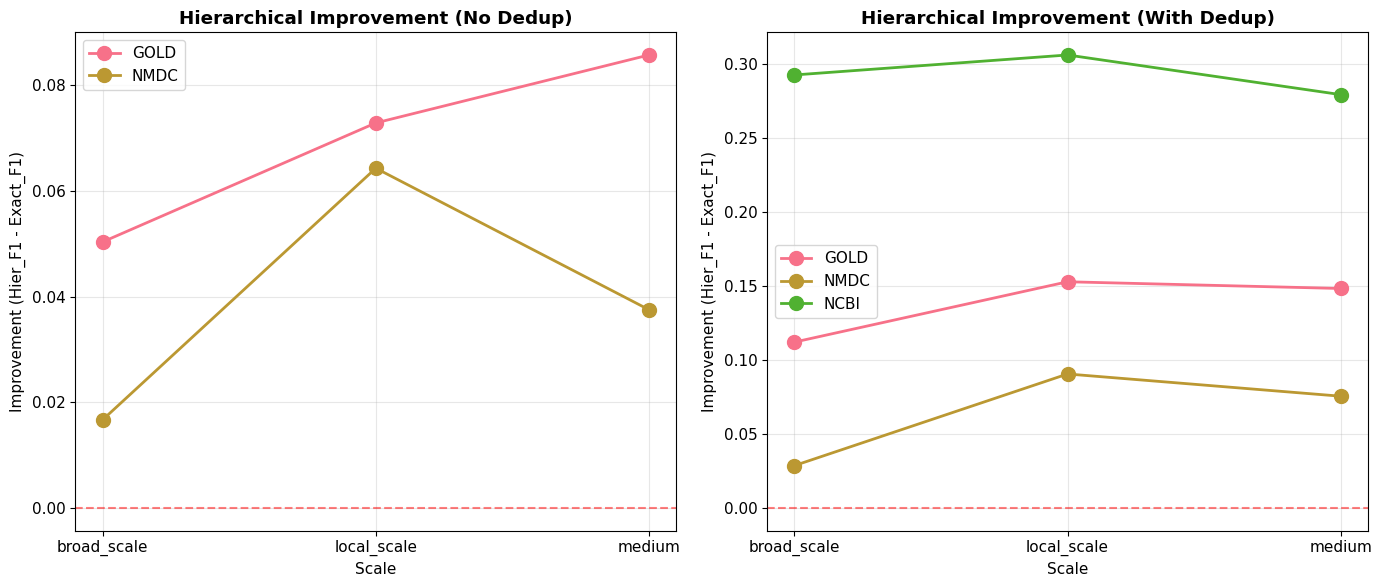

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for source in df_no_dedup['Source'].unique():
    data = df_no_dedup[df_no_dedup['Source'] == source]
    ax1.plot(data['Scale'], data['Improvement'], marker='o', linewidth=2,
            markersize=10, label=source)

ax1.set_title('Hierarchical Improvement (No Dedup)', fontweight='bold')
ax1.set_xlabel('Scale')
ax1.set_ylabel('Improvement (Hier_F1 - Exact_F1)')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)

for source in df_dedup['Source'].unique():
    data = df_dedup[df_dedup['Source'] == source]
    ax2.plot(data['Scale'], data['Improvement'], marker='o', linewidth=2,
            markersize=10, label=source)

ax2.set_title('Hierarchical Improvement (With Dedup)', fontweight='bold')
ax2.set_xlabel('Scale')
ax2.set_ylabel('Improvement (Hier_F1 - Exact_F1)')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Visualization: Score Distribution (Dedup)

In [14]:
score_data = []
for source in sorted(hier_results_dedup.keys()):
    for scale in ['env_broad_scale', 'env_local_scale', 'env_medium']:
        if scale not in hier_results_dedup[source]:
            continue
        scores = np.array(hier_results_dedup[source][scale]['scores'])
        score_data.append({
            'Source': source,
            'Scale': scale.replace('env_', ''),
            'Exact_F1_1.0': np.sum(scores == 1.0),
            '1hop_0.75': np.sum(scores == 0.75),
            '2hop_0.50': np.sum(scores == 0.50),
            '3+hop_0.25': np.sum(scores == 0.25),
            'Unrelated_0.0': np.sum(scores == 0.0),
        })

df_scores = pd.DataFrame(score_data)
print(df_scores.to_string(index=False))

Source       Scale  Exact_F1_1.0  1hop_0.75  2hop_0.50  3+hop_0.25  Unrelated_0.0
  GOLD broad_scale           678         80         82           0              0
  GOLD local_scale           563         11        253           0             13
  GOLD      medium           607         42        191           0              0
  NCBI broad_scale          4288        369       9841           0            142
  NCBI local_scale          3749         91      10300           0            500
  NCBI      medium          4560        537       9166           0            377
  NMDC broad_scale           891          3         36           0              0
  NMDC local_scale           773          2        155           0              0
  NMDC      medium           798          6        126           0              0


## Visualization: Score Distribution Stacked Bars

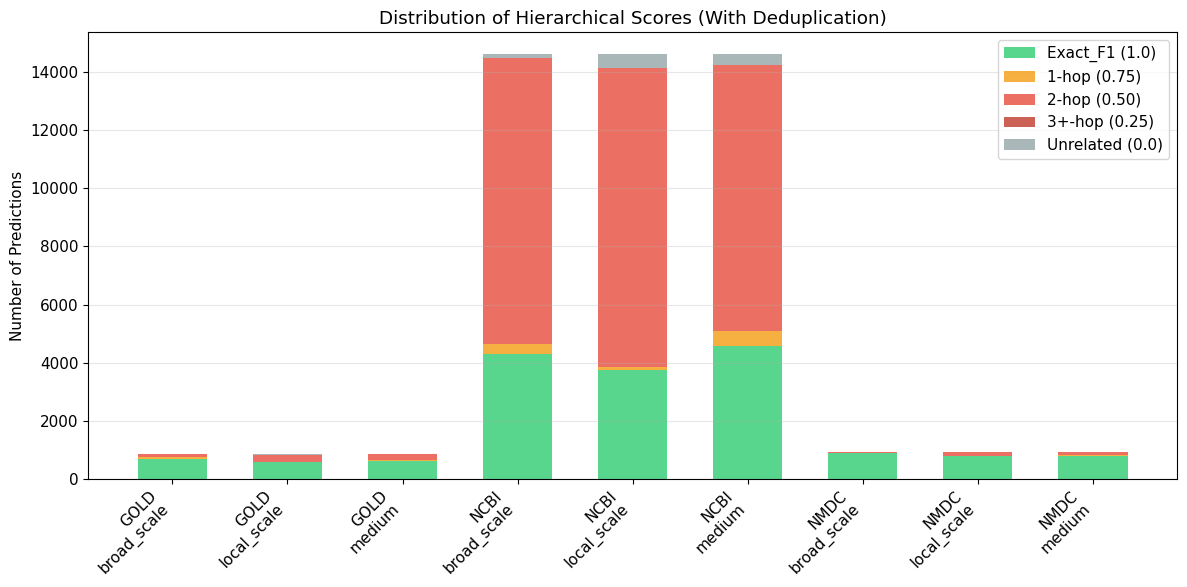

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_scores))
width = 0.6
bottom = np.zeros(len(df_scores))

colors = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b', '#95a5a6']
labels = ['Exact_F1 (1.0)', '1-hop (0.75)', '2-hop (0.50)', '3+-hop (0.25)', 'Unrelated (0.0)']
columns = ['Exact_F1_1.0', '1hop_0.75', '2hop_0.50', '3+hop_0.25', 'Unrelated_0.0']

for col, label, color in zip(columns, labels, colors):
    ax.bar(x, df_scores[col], width, label=label, bottom=bottom, color=color, alpha=0.8)
    bottom += df_scores[col].values

ax.set_ylabel('Number of Predictions')
ax.set_title('Distribution of Hierarchical Scores (With Deduplication)')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Source']}\n{r['Scale']}" for _, r in df_scores.iterrows()],
                   rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Visualization: By-Source Comparison (Dedup)

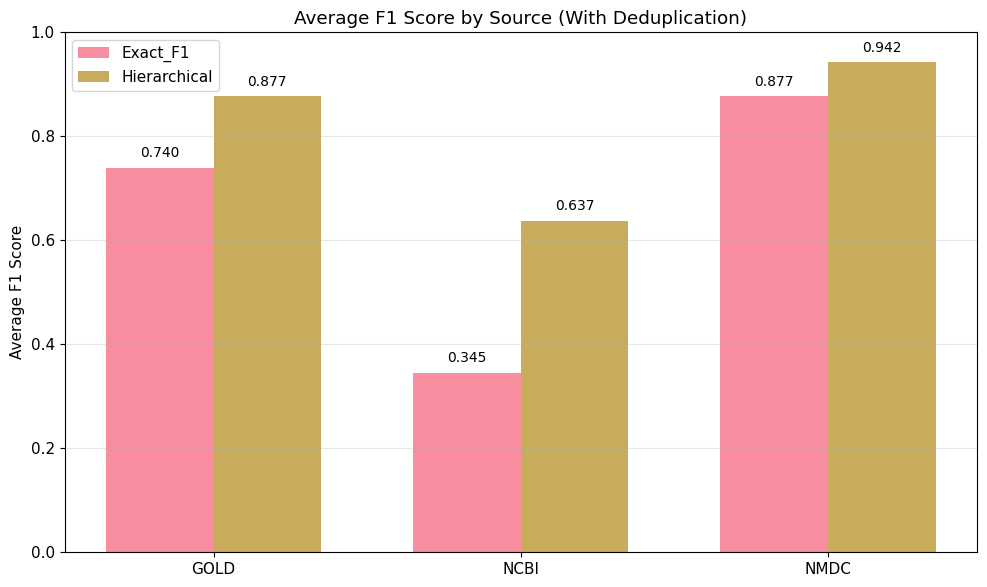

In [16]:
summary_src = df_dedup.groupby('Source')[['Exact_F1', 'Hier_F1']].mean()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(summary_src))
width = 0.35

ax.bar(x - width/2, summary_src['Exact_F1'], width, label='Exact_F1', alpha=0.8)
ax.bar(x + width/2, summary_src['Hier_F1'], width, label='Hierarchical', alpha=0.8)

ax.set_ylabel('Average F1 Score')
ax.set_title('Average F1 Score by Source (With Deduplication)')
ax.set_xticks(x)
ax.set_xticklabels(summary_src.index)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (exact, hier) in enumerate(zip(summary_src['Exact_F1'], summary_src['Hier_F1'])):
    ax.text(i - width/2, exact + 0.02, f'{exact:.3f}', ha='center', fontsize=10)
    ax.text(i + width/2, hier + 0.02, f'{hier:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Visualization: By-Scale Comparison

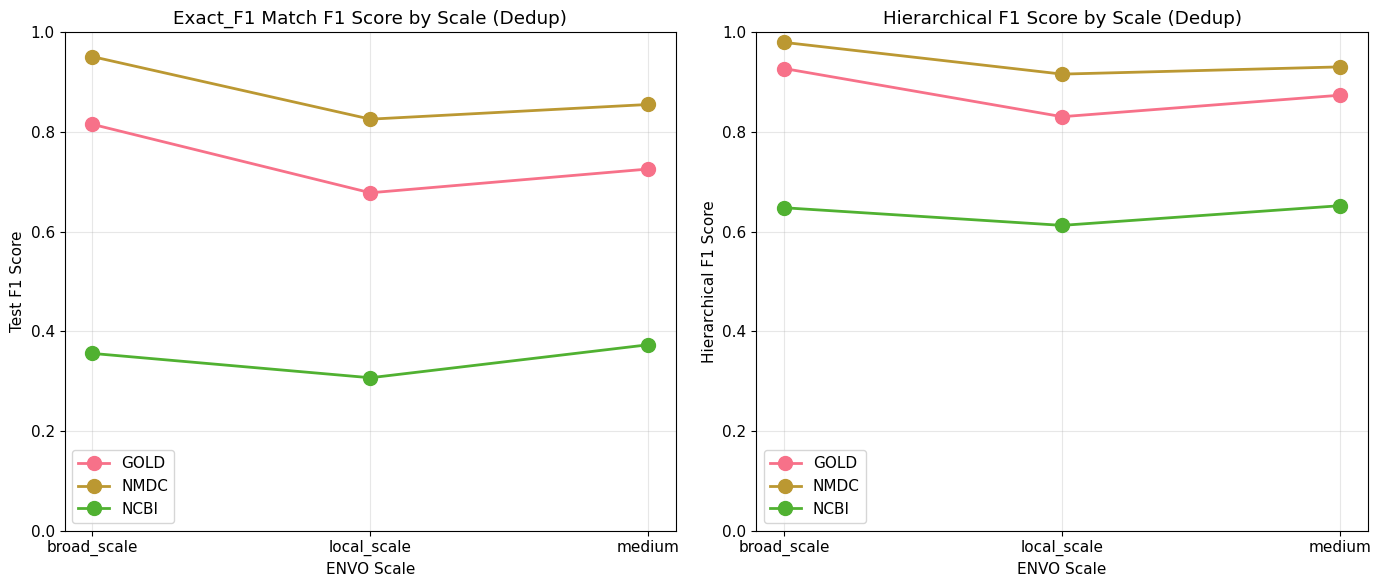

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for source in df_dedup['Source'].unique():
    data = df_dedup[df_dedup['Source'] == source]
    ax1.plot(data['Scale'], data['Exact_F1'], marker='o', linewidth=2,
            markersize=10, label=source)

ax1.set_title('Exact_F1 Match F1 Score by Scale (Dedup)')
ax1.set_xlabel('ENVO Scale')
ax1.set_ylabel('Test F1 Score')
ax1.set_ylim(0, 1.0)
ax1.legend()
ax1.grid(alpha=0.3)

for source in df_dedup['Source'].unique():
    data = df_dedup[df_dedup['Source'] == source]
    ax2.plot(data['Scale'], data['Hier_F1'], marker='o', linewidth=2,
            markersize=10, label=source)

ax2.set_title('Hierarchical F1 Score by Scale (Dedup)')
ax2.set_xlabel('ENVO Scale')
ax2.set_ylabel('Hierarchical F1 Score')
ax2.set_ylim(0, 1.0)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison: Deduplication Impact on Hierarchical Scoring

In [18]:
comparison_rows = []
for i, row_dedup in df_dedup.iterrows():
    source = row_dedup['Source']
    scale = row_dedup['Scale']

    row_no_dedup = df_no_dedup[(df_no_dedup['Source'] == source) &
                               (df_no_dedup['Scale'] == scale)]

    if len(row_no_dedup) > 0:
        comparison_rows.append({
            'Source': source,
            'Scale': scale,
            'Hier_F1_NoDedup': row_no_dedup.iloc[0]['Hier_F1'],
            'Hier_F1_Dedup': row_dedup['Hier_F1'],
            'Hier_F1_Delta': row_dedup['Hier_F1'] - row_no_dedup.iloc[0]['Hier_F1'],
        })

df_dedup_impact = pd.DataFrame(comparison_rows)
print('\nDeduplication Impact on Hierarchical F1 Score:')
print(df_dedup_impact.to_string(index=False))


Deduplication Impact on Hierarchical F1 Score:
Source       Scale  Hier_F1_NoDedup  Hier_F1_Dedup  Hier_F1_Delta
  GOLD broad_scale         0.969125       0.927381      -0.041744
  GOLD local_scale         0.892960       0.830655      -0.062305
  GOLD      medium         0.919270       0.873810      -0.045460
  NMDC broad_scale         0.983231       0.979839      -0.003392
  NMDC local_scale         0.934769       0.916129      -0.018640
  NMDC      medium         0.952923       0.930645      -0.022278


## Summary

In [19]:
print('\n' + '='*80)
print('SUMMARY: Hierarchical Scoring Impact')
print('='*80)

print('\nNo Deduplication:')
print(f'  Exact_F1 F1:      {df_no_dedup["Exact_F1"].mean():.4f}')
print(f'  Hierarchical F1: {df_no_dedup["Hier_F1"].mean():.4f}')
print(f'  Mean improvement:    +{df_no_dedup["Improvement"].mean():.4f}')
print(f'  Max improvement:     +{df_no_dedup["Improvement"].max():.4f}')

print('\nWith Deduplication:')
print(f'  Exact_F1 F1:      {df_dedup["Exact_F1"].mean():.4f}')
print(f'  Hierarchical F1: {df_dedup["Hier_F1"].mean():.4f}')
print(f'  Mean improvement:    +{df_dedup["Improvement"].mean():.4f}')
print(f'  Max improvement:     +{df_dedup["Improvement"].max():.4f}')

print('\nBy Source (Dedup):')
for source in df_dedup['Source'].unique():
    source_data = df_dedup[df_dedup['Source'] == source]
    exact_avg = source_data['Exact_F1'].mean()
    hier_avg = source_data['Hier_F1'].mean()
    improvement = hier_avg - exact_avg
    print(f'  {source:10s}: {exact_avg:.4f} -> {hier_avg:.4f} (+{improvement:.4f})')

print('\n' + '='*80)


SUMMARY: Hierarchical Scoring Impact

No Deduplication:
  Exact_F1 F1:      0.8875
  Hierarchical F1: 0.9420
  Mean improvement:    +0.0546
  Max improvement:     +0.0857

With Deduplication:
  Exact_F1 F1:      0.6540
  Hierarchical F1: 0.8190
  Mean improvement:    +0.1650
  Max improvement:     +0.3059

By Source (Dedup):
  GOLD      : 0.7397 -> 0.8773 (+0.1376)
  NMDC      : 0.8774 -> 0.9422 (+0.0648)
  NCBI      : 0.3450 -> 0.6375 (+0.2925)

